DATA ANALYSIS AND DATA SCIENCE
LA GUARDIA COMMUNITY COLLEGE
NEW YORK

Online Retail - Data Analysis

APA REF;
Chen, D. (2015). Online Retail [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33.

Data from = https://archive.ics.uci.edu/dataset/352/online+retail$0

Online Retail
Donated on 11/5/2015


INFO:

This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

Dataset Characteristics
Multivariate, Sequential, Time-Series

Subject Area
Business

# Instances
541909

Additional Information

The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

Has Missing Values?
No



In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
url = ('https://docs.google.com/spreadsheets/d/1BO9XQ-NQ13GBn47rQcqP3Vv025CjgNOZ/export?format=csv')


In [39]:

df = pd.read_csv(url)
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [40]:
shape = df.shape

print(f'There are {shape[0]} Rows and {shape[1]} columns')

There are 541909 Rows and 8 columns


In [41]:
df.index

RangeIndex(start=0, stop=541909, step=1)

In [42]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [44]:
df.count()

,0
InvoiceNo,541909
StockCode,541909
Description,540455
Quantity,541909
InvoiceDate,541909
UnitPrice,541909
CustomerID,406829
Country,541909


CLEANING DATA

In [45]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [46]:
df = df.dropna(subset=['Description'])

In [47]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133626
Country,0


Which products are selling best in this dataset?

In [48]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(30)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
JUMBO BAG RED RETROSPOT,47363
ASSORTED COLOUR BIRD ORNAMENT,36381
POPCORN HOLDER,36334
PACK OF 72 RETROSPOT CAKE CASES,36039
WHITE HANGING HEART T-LIGHT HOLDER,35317
RABBIT NIGHT LIGHT,30680
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26315


Which countries show the strongest product sales in this dataset?

In [49]:
df.groupby(['Description','Country'])['Quantity'].sum().sort_values(ascending=False).head(30)

,,Quantity
Description,Country,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,United Kingdom,48326
JUMBO BAG RED RETROSPOT,United Kingdom,43167
POPCORN HOLDER,United Kingdom,34365
ASSORTED COLOUR BIRD ORNAMENT,United Kingdom,33679
WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,33193
PACK OF 12 LONDON TISSUES,United Kingdom,25307
PACK OF 72 RETROSPOT CAKE CASES,United Kingdom,24702
VICTORIAN GLASS HANGING T-LIGHT,United Kingdom,23242
BROCADE RING PURSE,United Kingdom,22801


BAR CHART

<Axes: xlabel='Quantity', ylabel='Label'>

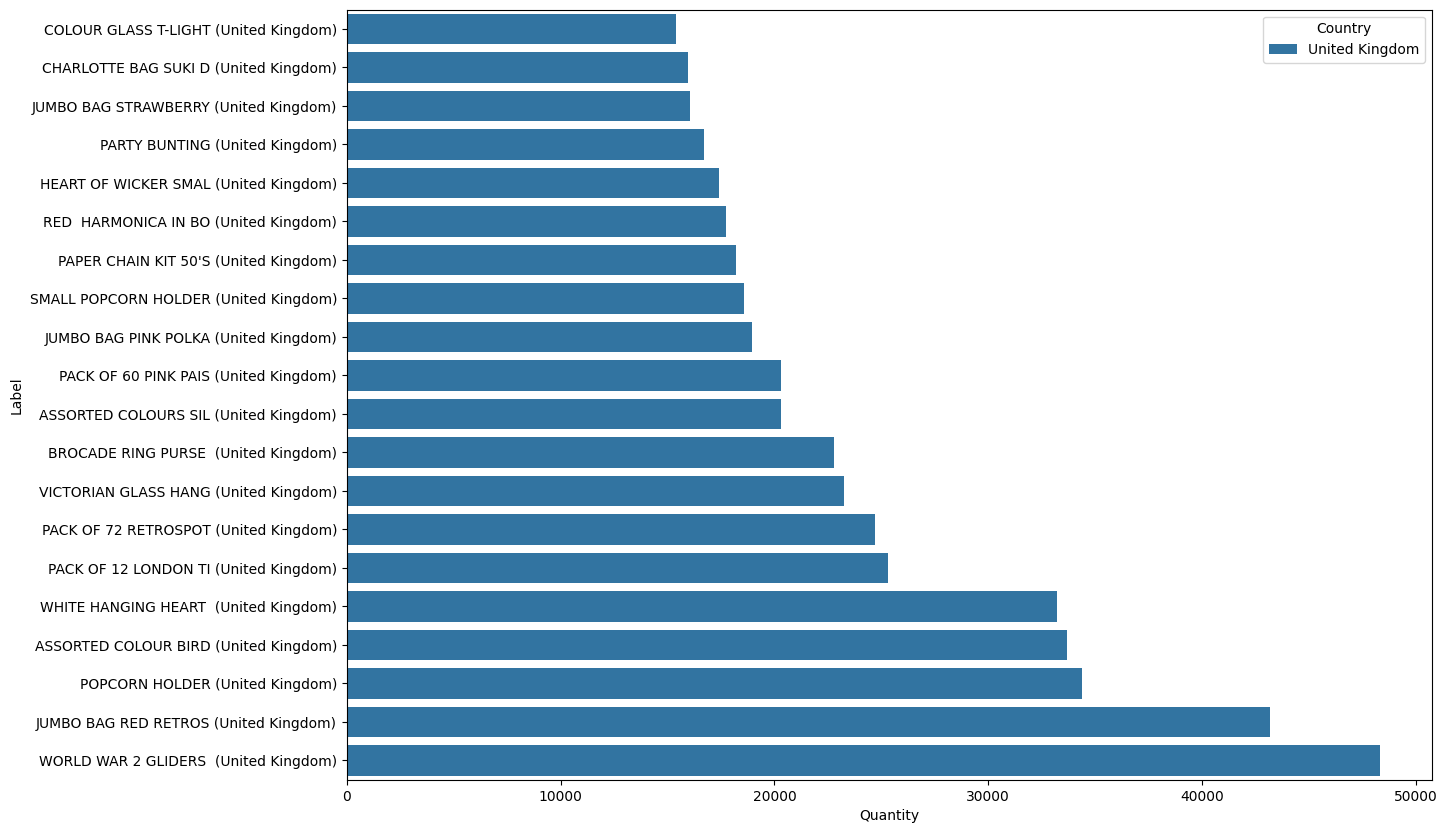

In [50]:
# Group by Description and Country
top_20 = (
    df.groupby(['Description', 'Country'])['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

# Create label combining product + country
top_20['Label'] = (
    top_20['Description'].str[:20] + ' (' + top_20['Country'] + ')'
)

# Sort for horizontal bar chart
top_20 = top_20.sort_values('Quantity', ascending=True)

# Plot
plt.figure(figsize=(14, 10))

sns.barplot(
    data=top_20,
    x='Quantity',
    y='Label',
    hue='Country',
    dodge=False,
    legend=True
)

Which countries have sold the highest total quantity of products?

In [51]:
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(20)


,Quantity
Country,
United Kingdom,4277438
Netherlands,200128
EIRE,142637
Germany,117448
France,110480
Australia,83653
Sweden,35637
Switzerland,30325
Spain,26824


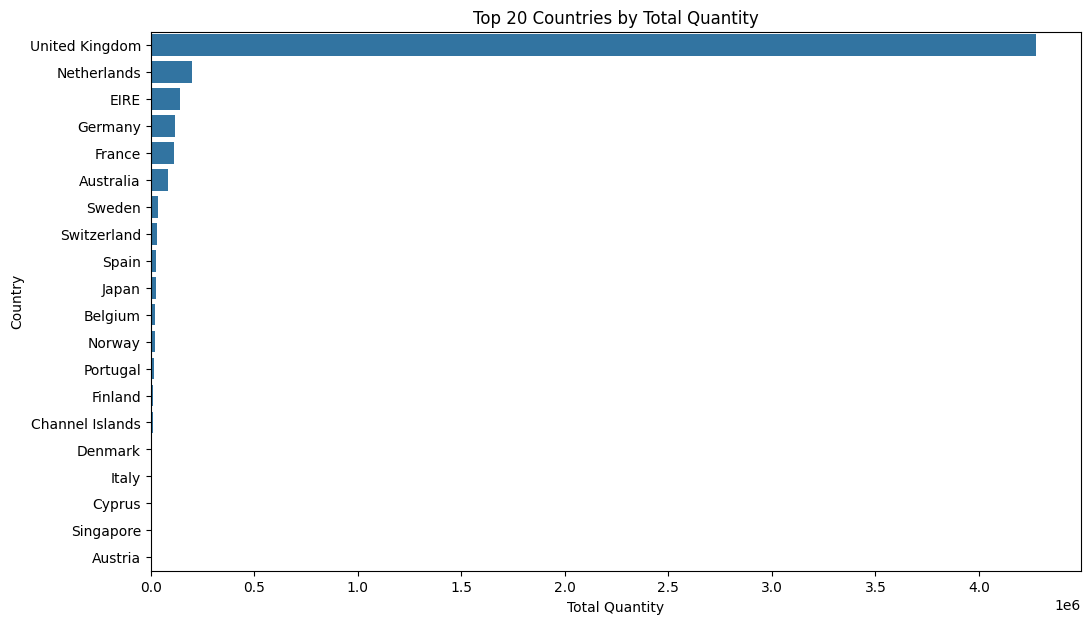

In [52]:
top_countries = (
    df.groupby('Country')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x='Quantity',
    y='Country'
)

plt.title('Top 20 Countries by Total Quantity')
plt.xlabel('Total Quantity')
plt.ylabel('Country')

plt.show()

In [53]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

The following metrics:
Quantity: Total quantity of products sold (sum)
Unit Price: Average unit price (mean)
Total Sales: Total sales revenue (sum)

In [54]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

df.groupby('Country').agg({
    'Quantity'  : 'sum',
    'UnitPrice' : 'mean',
    'TotalSales': 'sum'
}).sort_values('TotalSales', ascending=False).head(10)

,Quantity,UnitPrice,TotalSales
Country,,,
United Kingdom,4277438,4.545762,8187806.364
Netherlands,200128,2.738317,284661.540
EIRE,142637,5.911077,263276.820
Germany,117448,3.966930,221698.210
France,110480,5.028864,197403.900
Australia,83653,3.220612,137077.270
Switzerland,30325,3.403442,56385.350
Spain,26824,4.987544,54774.580
Belgium,23152,3.644335,40910.960


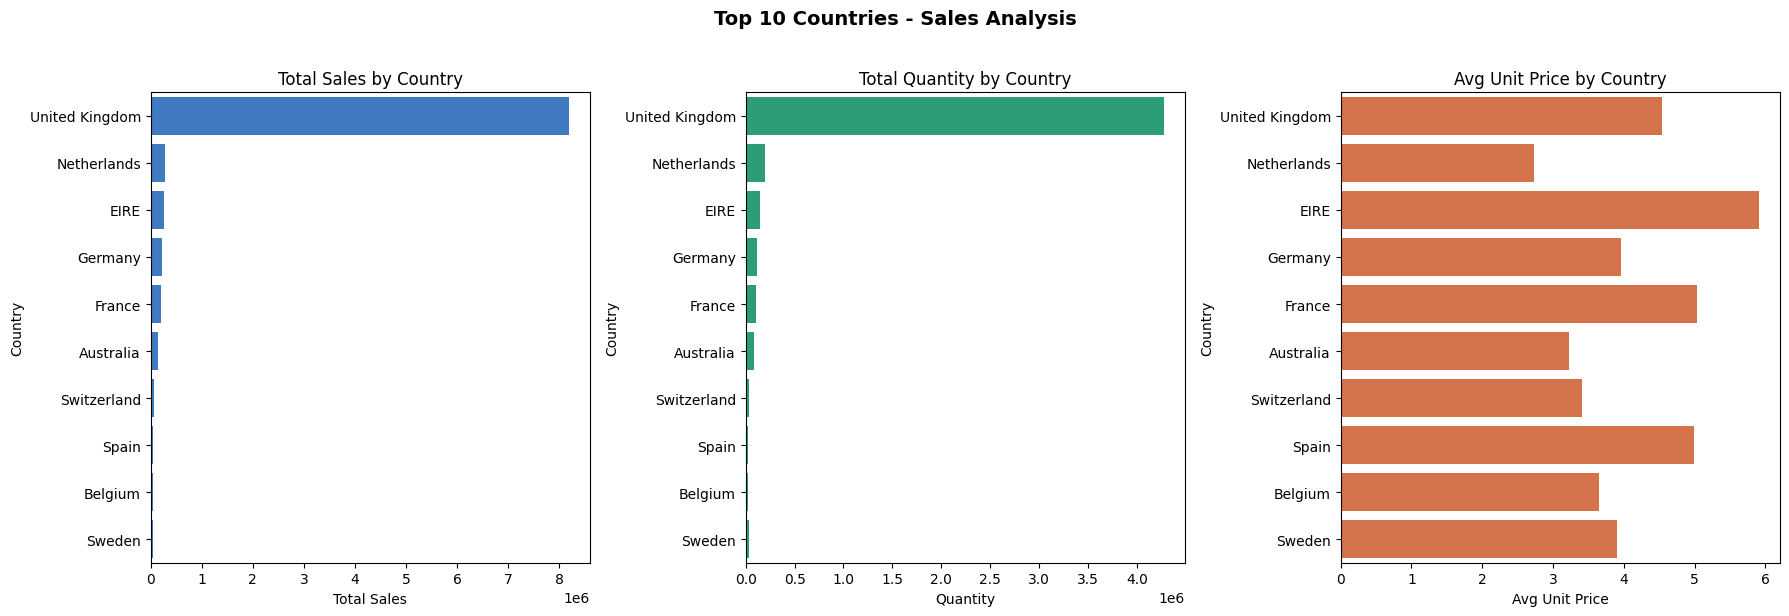

In [55]:
# Creating data
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

top10 = (
    df.groupby('Country').agg({
        'Quantity'  : 'sum',
        'UnitPrice' : 'mean',
        'TotalSales': 'sum'
    })
    .sort_values('TotalSales', ascending=False)
    .head(10)
    .reset_index()
)

# Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# TotalSales
sns.barplot(data=top10, x='TotalSales', y='Country', ax=axes[0], color='#2a78d6')
axes[0].set_title('Total Sales by Country')
axes[0].set_xlabel('Total Sales')

# Quantity
sns.barplot(data=top10, x='Quantity', y='Country', ax=axes[1], color='#1baf7a')
axes[1].set_title('Total Quantity by Country')
axes[1].set_xlabel('Quantity')

# Avg UnitPrice
sns.barplot(data=top10, x='UnitPrice', y='Country', ax=axes[2], color='#eb6834')
axes[2].set_title('Avg Unit Price by Country')
axes[2].set_xlabel('Avg Unit Price')

plt.suptitle('Top 10 Countries - Sales Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

APA REF

Chen, D. (2015). Online Retail [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33.
